2026-06-08 08:00:51.405093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780905651.631944      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780905651.697848      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780905652.257601      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780905652.257646      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780905652.257649      16 computation_placer.cc:177] computation placer alr

Searching for dataset paths dynamically...
Dynamic Match - Training Path: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Dynamic Match - Testing Path:  /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


2026-06-08 08:01:51.214254: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model compiled successfully with Custom Double-Arctan Loss! Starting training loop...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1996s 6s/step - accuracy: 0.7285 - loss: 0.0868 - val_accuracy: 0.8131 - val_loss: 0.0625
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 2012s 6s/step - accuracy: 0.8158 - loss: 0.0620 - val_accuracy: 0.8417 - val_loss: 0.0554
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 2081s 6s/step - accuracy: 0.8275 - loss: 0.0583 - val_accuracy: 0.8374 - val_loss: 0.0555
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1977s 6s/step - accuracy: 0.8390 - loss: 0.0551 - val_accuracy: 0.8402 - val_loss: 0.0564
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1972s 6s/step - accuracy: 0.8451 - loss: 0.0528 - val_accuracy: 0.8566 - val_loss: 0.0518
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 2024s 6s/step - accuracy: 0.8486 - loss: 0.0515 - val_accuracy: 0.8402 - val_loss: 0.0548
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1992s 6s/step - accuracy: 0.8546 - loss: 0.

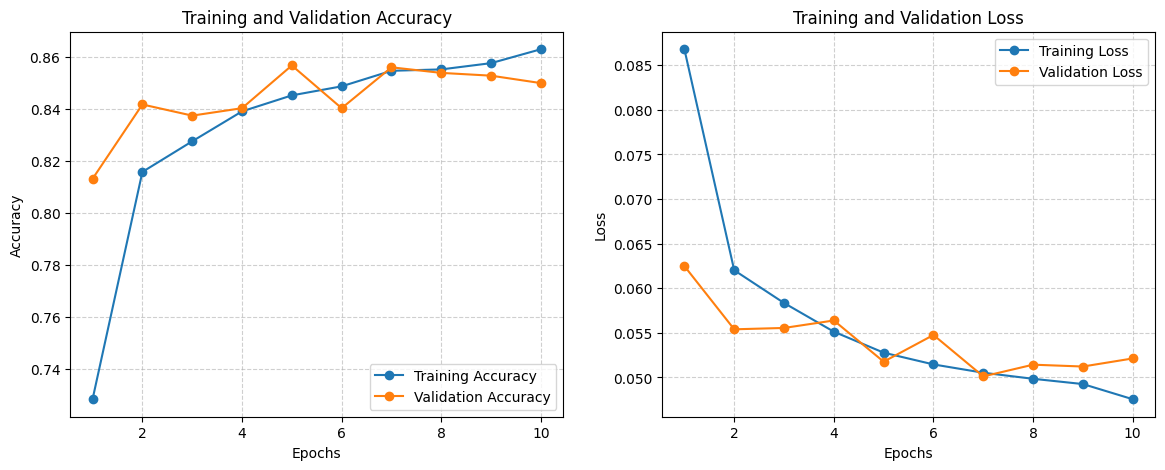


All tasks completed! Model weights saved securely to: /kaggle/working/intel_vgg19_classifier.h5


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report

print("Searching for dataset paths dynamically...")
TRAIN_DIR = None
TEST_DIR = None

for root, dirs, _ in os.walk('/kaggle/input'):
    if 'buildings' in dirs and 'forest' in dirs:
        if 'train' in root.lower():
            TRAIN_DIR = root
        elif 'test' in root.lower():
            TEST_DIR = root

if not TRAIN_DIR or not TEST_DIR:
    print("Auto-detection failed. Current directories under /kaggle/input:")
    if os.path.exists('/kaggle/input'):
        print(os.listdir('/kaggle/input'))
    raise FileNotFoundError("Could not locate the Intel Image folders.")

print(f"Dynamic Match - Training Path: {TRAIN_DIR}")
print(f"Dynamic Match - Testing Path:  {TEST_DIR}")
print("="*60)

BATCH_SIZE = 32
IMG_SIZE = (150, 150)

@tf.keras.utils.register_keras_serializable()
class BoundedDoubleArctanLoss(tf.keras.losses.Loss):
    def __init__(self, name="bounded_double_arctan_loss", **kwargs):
        super().__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        sq_error = tf.square(y_pred - y_true)
        arctan_term = tf.atan(sq_error)
        exp_arctan_term = tf.exp(tf.atan(sq_error))
        eps = 1e-4
        elementwise_loss = (arctan_term * exp_arctan_term) + (eps * sq_error)
        return tf.reduce_mean(elementwise_loss, axis=-1)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config}

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

base_model = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

for layer in base_model.layers:
    layer.trainable = False 

x = base_model.output 
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(6, activation='softmax')(x) 

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss=BoundedDoubleArctanLoss(), metrics=['accuracy'])

print("Model compiled successfully with Custom Double-Arctan Loss! Starting training loop...")
print("="*60)

EPOCHS = 10
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS)

print("\n" + "="*60)
print(" STARTING MODEL TESTING PHASE")
print("="*60)

test_loss, test_acc = model.evaluate(test_gen)
print(f"\n Overall Test Accuracy: {test_acc*100:.2f}%")
print(f" Overall Test Loss: {test_loss:.4f}\n")

print("Generating predictions for classification report...")
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("\n=== PER-CLASS PERFORMANCE REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_labels))

print("\nGenerating training vs validation plots...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('/kaggle/working/training_performance_plots.png', bbox_inches='tight')
plt.show()

model_path = '/kaggle/working/intel_vgg19_classifier.h5'
model.save(model_path)
print(f"\nAll tasks completed! Model weights saved securely to: {model_path}")